In [11]:
import os
from pathlib import Path
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import tqdm
from datetime import datetime, timezone
import torch

from even_flow.utils import set_logger
from even_flow.moons.jobs import(
    MoonsTimeEmbeddingMLPCNFJob
)

logger = set_logger()
mlflow_tracking_path = Path(os.getcwd()).absolute() / 'mlruns'
mlflow.set_tracking_uri(f'file://{mlflow_tracking_path}')
logger.info(f'Set MLflow tracking URI to {mlflow.get_tracking_uri()}')

2025-12-15 18:50:30 | INFO | root | 2431296698 | 20 | Set MLflow tracking URI to file:///home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/mlruns


In [2]:
experiment_name = 'Moons Exact CNF Corrected Div Scale Addition'
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
runs_df = runs_df[runs_df['status'] == 'FINISHED']
runs_df.sort_values(by='metrics.train.loss', inplace=True, ascending=True)
runs_df

/home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.fit_duration,metrics.val.scaled_logp_z0,metrics.exec_start,metrics.train_z0_epoch,...,params.model.rtol,params.dataset.batch_size,params.model.checkpoint.monitor,params.model.profiler,params.model.solver,params.model.early_stopping.monitor,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
9,76646dccc7f54edf920d276385c57f22,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:07:11.079000+00:00,2025-12-15 18:08:27.826000+00:00,70.841848,-7.258590,1.765822e+09,0.37549,...,0.01,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-110,LOCAL
14,478c3c8adbbc4a1f8973399d07511bc2,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:04:50.848000+00:00,2025-12-15 18:05:50.797000+00:00,54.810240,-7.455790,1.765822e+09,0.37549,...,0.01,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-105,LOCAL
44,1cc1869b610a450880f9be13de924dd1,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:46:35.118000+00:00,2025-12-15 17:48:55.592000+00:00,126.402632,-7.943860,1.765821e+09,0.37549,...,0.001,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-75,LOCAL
69,55cc9f2888de499da029adfa84ded766,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:26:32.012000+00:00,2025-12-15 17:28:51.876000+00:00,127.348390,-7.979869,1.765820e+09,0.37549,...,0.0001,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-50,LOCAL
99,fea7209675fd4c59afefed839bb55a96,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:00:53.761000+00:00,2025-12-15 17:03:33.032000+00:00,142.564411,-8.014627,1.765818e+09,0.37549,...,9.999999999999999e-06,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-20,LOCAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,a648c819569140b6ad1cc64dcac0b2f0,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:36:53.204000+00:00,2025-12-15 17:40:41.447000+00:00,214.965922,-68816.632812,1.765820e+09,0.37549,...,0.001,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-68,LOCAL
75,ca9c1dda6aef44e7bd01712f726aba57,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:19:19.582000+00:00,2025-12-15 17:30:05.089000+00:00,617.876172,-103615.445312,1.765819e+09,0.37549,...,0.0001,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-44,LOCAL
81,64406d2e469744af8119a69217a19f3b,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:13:43.029000+00:00,2025-12-15 17:23:15.644000+00:00,541.728507,-123554.500000,1.765819e+09,0.37549,...,0.0001,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-38,LOCAL
15,0e09157f80e14e7cbb6162f5c68f3727,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:04:32.411000+00:00,2025-12-15 18:08:07.588000+00:00,203.033171,-143017.250000,1.765822e+09,0.37549,...,0.01,32,val_loss,simple,dopri5,val_loss,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-104,LOCAL


In [3]:
for i, col in enumerate(runs_df.columns):
    if not (col.startswith('metrics.train') and col.endswith('epoch')):
        continue
    print(f'{i} - {col}')

9 - metrics.train_z0_epoch
10 - metrics.train_zf_epoch
23 - metrics.train_logp_z0_epoch
31 - metrics.train_scaled_int_div_epoch
58 - metrics.train_int_div_epoch
61 - metrics.train_logp_zf_epoch
64 - metrics.train_loss_epoch
79 - metrics.train_scaled_logp_z0_epoch


/tmp/ipykernel_1539538/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')


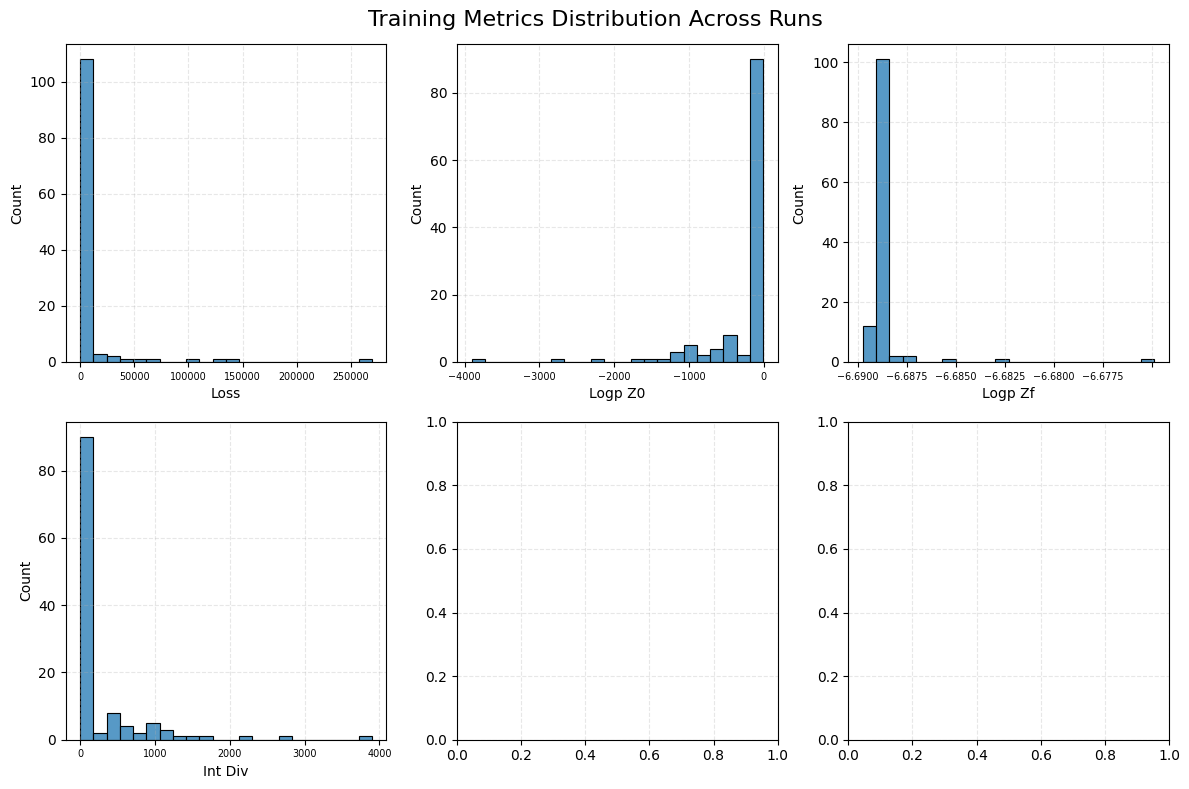

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
x_values = [
    'metrics.train.loss',
    'metrics.train.logp_z0',
    'metrics.train.logp_zf',
    'metrics.train.int_div',
]
for ax in axes.flatten():
    ax.grid(alpha=.3, linestyle='--')
for i in range(len(x_values)):
    x = x_values[i]
    metric_name = x.split('.')[-1]
    ax = axes.flatten()[i] if len(x_values) > 1 else axes
    # ax.set_xscale('log')
    ax.grid(alpha=.3, linestyle='--')
    ax.set(
        xlabel=' '.join(metric_name.split('_')).title(),
    )
    sns.histplot(
        data=runs_df,
        x=x,
        ax=ax,
    )
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
fig.suptitle('Training Metrics Distribution Across Runs', fontsize=16)
fig.tight_layout()

/tmp/ipykernel_1539538/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1539538/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')


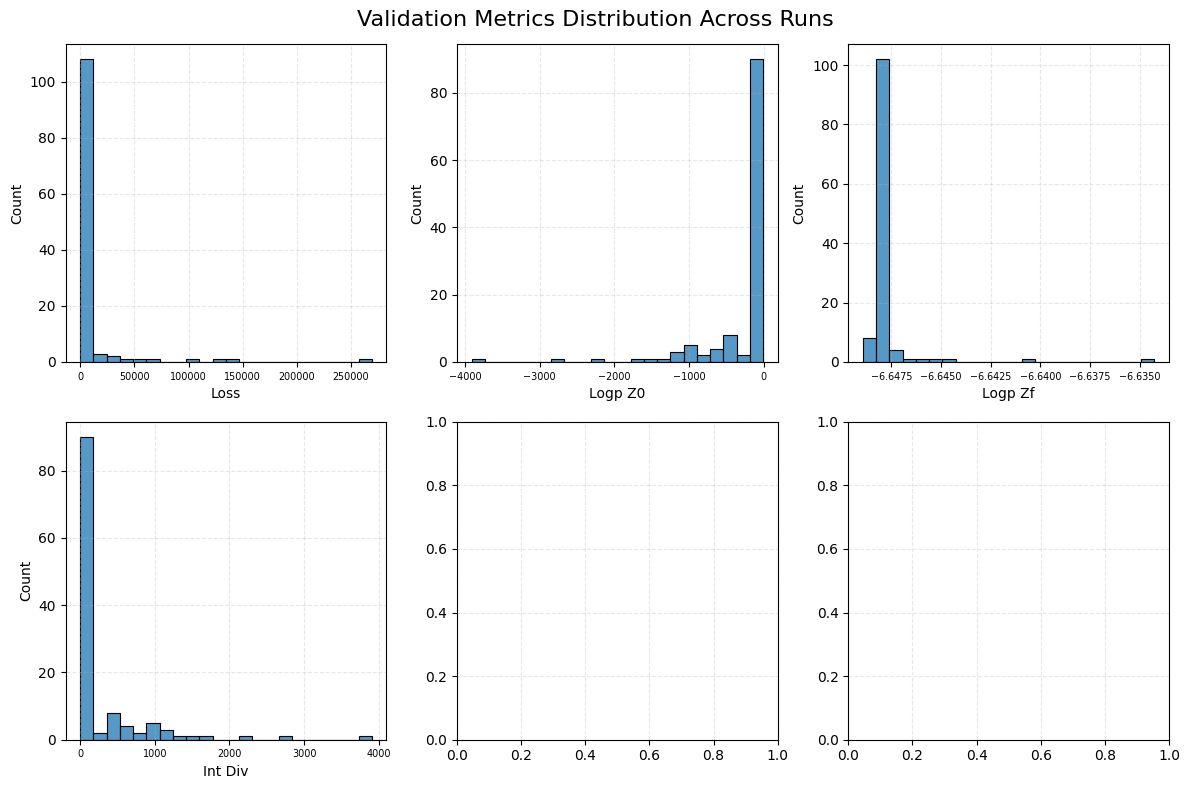

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
x_values = [
    'metrics.val.loss',
    'metrics.val.logp_z0',
    'metrics.val.logp_zf',
    'metrics.val.int_div',
]
for ax in axes.flatten():
    ax.grid(alpha=.3, linestyle='--')
for i in range(len(x_values)):
    x = x_values[i]
    metric_name = x.split('.')[-1]
    ax = axes.flatten()[i] if len(x_values) > 1 else axes
    # ax.set_xscale('log')
    ax.grid(alpha=.3, linestyle='--')
    ax.set(
        xlabel=' '.join(metric_name.split('_')).title(),
    )
    sns.histplot(
        data=runs_df,
        x=x,
        ax=ax,
    )
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
fig.suptitle('Validation Metrics Distribution Across Runs', fontsize=16)
fig.tight_layout()

In [6]:
min_val_loss_run = runs_df.loc[runs_df['metrics.val.loss'].idxmin()]
min_val_loss_job = MoonsTimeEmbeddingMLPCNFJob.from_mlflow_run_id(min_val_loss_run['run_id'])
min_val_loss_job

/home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MoonsTimeEmbeddingMLPCNFJob(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='', slurm=SlurmEnvironment(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='slurm', job_id='1202', job_name='run_moons', array_job_id='1090', array_task_id='110'), dataset=MoonsDataset(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='dataset', train_samples=10000, val_samples=1000, test_samples=1000, noise=0.05, batch_size=32, random_state=943874), model=TimeEmbeddingMLPCNFModel(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='model', accelerator='cpu', profiler='simple', max_epochs=50, num_sanity_val_steps=5, enable_progress_bar=False, enable_model_summary=True, max_time={'hours': 11}, gradient_clip_val=None, checkpoint=ModelCheckpointConfig(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='model.checkpoint', dirpath=None, monitor='val_loss', mode='min', save_top_k=3, filename='

In [7]:
y_values = [
    'epoch',
    'train_loss_epoch',
    'train_logp_z0_epoch',
    'train_logp_zf_epoch',
    'train_int_div_epoch',
]
label_map = {
    y: ' '.join(y.split('_')[1:-1]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
min_val_loss_metric_history = min_val_loss_job.get_metric_history(y_values).dropna()
min_val_loss_metric_history.rename(label_map, axis=1, inplace=True)
min_val_loss_metric_history

,Epoch,Loss,Logp Z0,Logp Zf,Int Div,step
312,0.0,6.575742,-6.575742,-6.687624,0.111879,312
625,1.0,6.198151,-6.198151,-6.691066,0.492915,625
938,2.0,6.104935,-6.104935,-6.689786,0.584853,938
1251,3.0,6.056841,-6.056841,-6.689451,0.632606,1251


In [8]:
y_values = [
    'epoch',
    'train_loss_epoch',
    'train_logp_z0_epoch',
    'train_logp_zf_epoch',
    'train_int_div_epoch',
]
label_map = {
    y: ' '.join(y.split('_')[1:-1]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
data = min_val_loss_job.get_metric_history(y_values).dropna()
data.rename(label_map, axis=1, inplace=True)

fig = px.line(
    data,
    x='Epoch',
    y=list(label_map.values()),
    title='Training Metrics Over Epochs for Best Validation Loss Run',
    markers=True
)
fig.update_layout(legend=dict(title='Variable'))
fig.show()

In [9]:
y_values = [
    'epoch',
    'val_loss',
    'val_logp_z0',
    'val_logp_zf',
    'val_int_div',
]
label_map = {
    y: ' '.join(y.split('_')[1:]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
data = min_val_loss_job.get_metric_history(y_values).dropna()
data.rename(label_map, axis=1, inplace=True)

fig = px.line(
    data,
    x='Epoch',
    y=list(label_map.values()),
    title='Validation Metrics Over Epochs for Best Validation Loss Run',
    markers=True
)
fig.update_layout(legend=dict(title='Variable'))
fig.show()

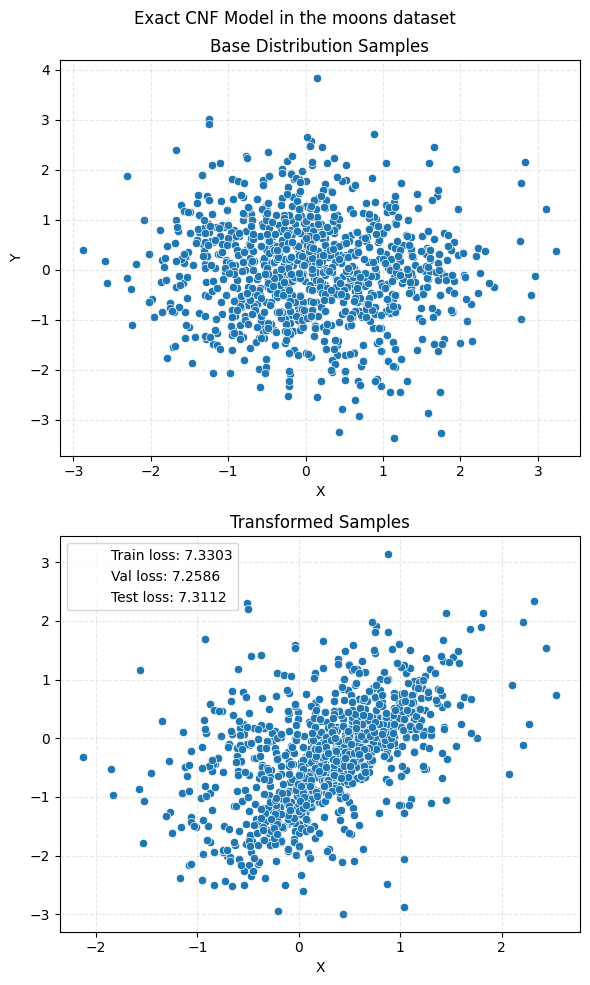

In [10]:
sample_time_estimation = 100
n_samples = 1000
# delta = []
# for _ in tqdm(range(sample_time_estimation), total=sample_time_estimation):
#     start = datetime.now(timezone.utc).timestamp()
#     min_val_loss_job.model.sample((n_samples,))
#     finish = datetime.now(timezone.utc).timestamp()
#     delta.append(finish - start)
# delta = np.array(delta)
# avg = np.mean(delta)
# std = np.std(delta)
# logger.info(f'Average sampling time over {sample_time_estimation} runs: {avg:.5f} ± {std:.5f} seconds')

fig, axes = plt.subplots(2, 1, figsize=(6, 10))
transformed_samples, base_samples, fig, axes = min_val_loss_job.plot_comparison(n_samples=n_samples, axes=axes)
fig.suptitle('Exact CNF Model in the moons dataset')
fig.tight_layout()
axes[1].plot([], [], ' ',
             label=f'Train loss: {min_val_loss_run["metrics.train.loss"]:.4f}',)
axes[1].plot([], [], ' ',
             label=f'Val loss: {min_val_loss_run["metrics.val.loss"]:.4f}',)
axes[1].plot([], [], ' ',
             label=f'Test loss: {min_val_loss_run["metrics.test.loss"]:.4f}',)
# axes[1].plot([], [], ' ',
#              label=f'Sample time: {avg:.4f} ± {std:.4f} seconds',)
axes[1].legend()

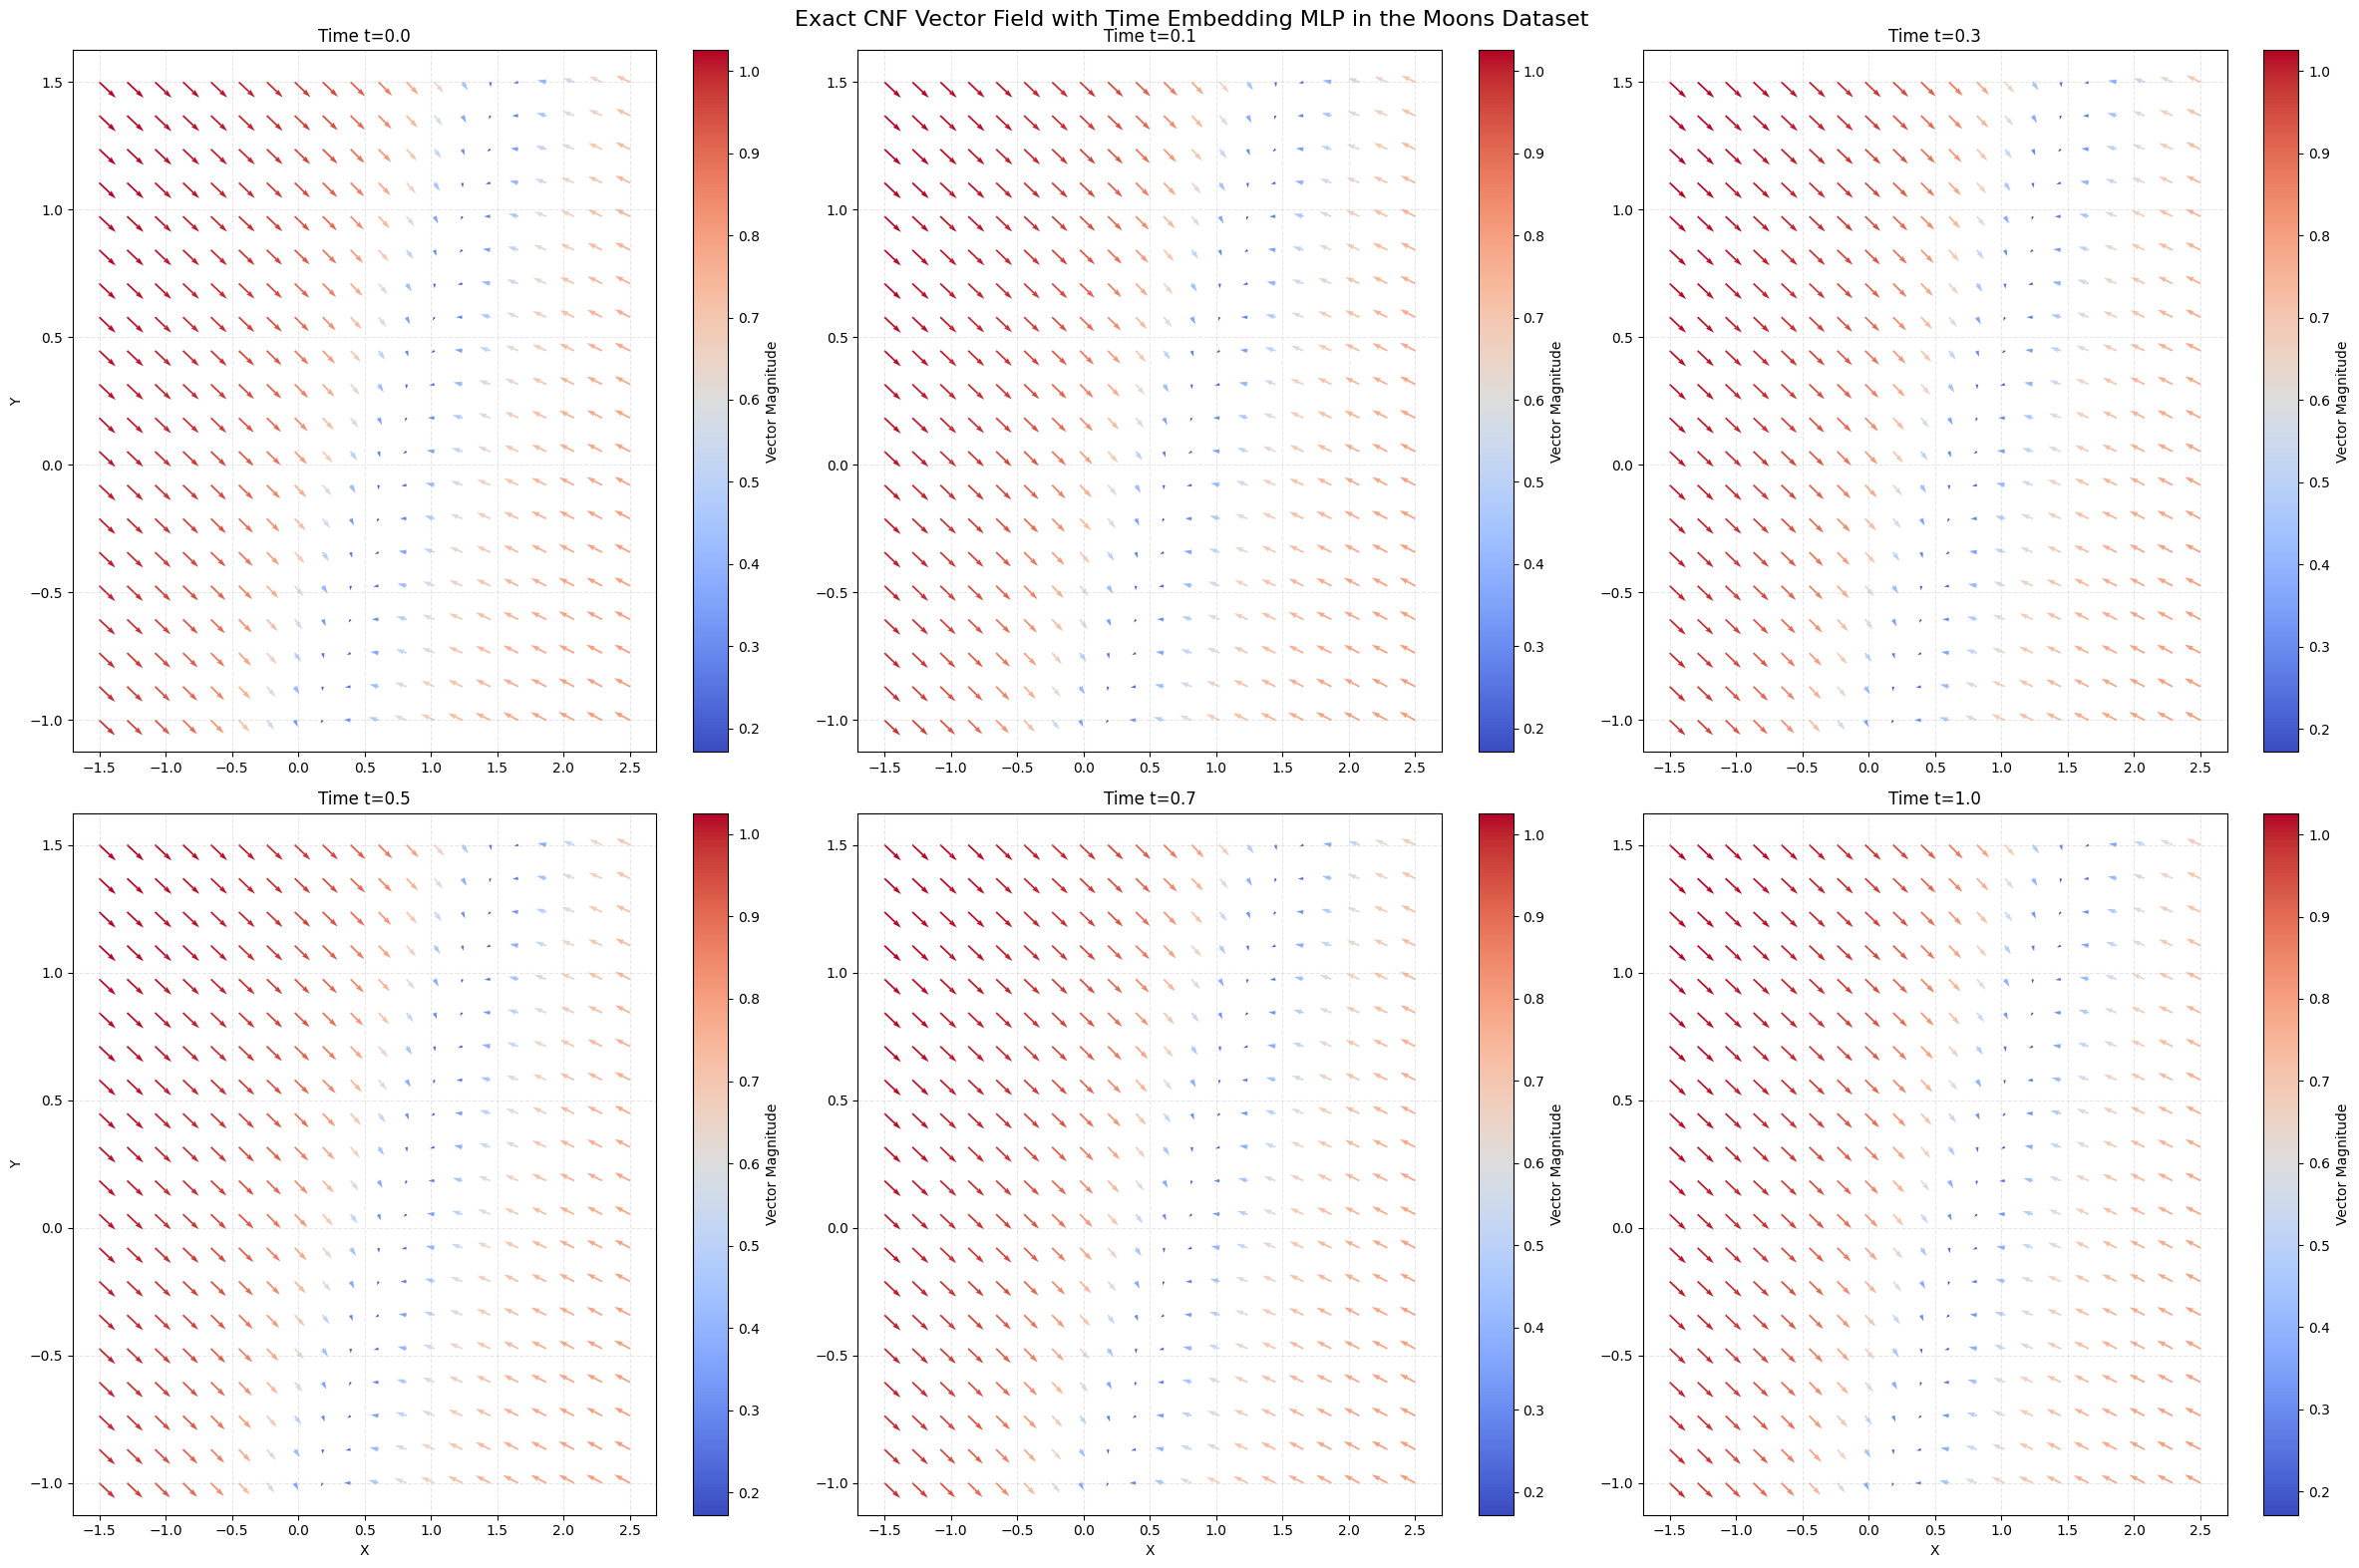

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for ax in axes[-1, :].flatten():
    ax.set_xlabel('X')
for ax in axes[:, 0].flatten():
    ax.set_ylabel('Y')
times = [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]
for t, ax in zip(times[::-1], axes.flatten()):
    ax.set_title(f'Time t={t}') 
    ax.grid(alpha=.3, linestyle='--')
    min_val_loss_job.vector_field_plot(
        x=torch.linspace(-1.5, 2.5, 20),
        y=torch.linspace(-1.0, 1.5, 20),
        t=t,
        ax=ax,
        cmap='coolwarm'
    )
fig.suptitle('Exact CNF Vector Field with Time Embedding MLP in the Moons Dataset', fontsize=16)
fig.tight_layout()